# TACTIC Files
This notebook contains the code used to generate all figures, tables, and data for the TACTIC manuscript.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

df = out['validation']['all_scores'].copy()
df = df[df['Strain'].str.startswith('PS')]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10.5, 4.5), constrained_layout=True)

# Generate figure
ax = axs[0]
sns.scatterplot(data=df, x='Bliss score (Manual)', y='Bliss score (SynergyFinder)', hue='Board type', ax=ax)
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
ax.set_title('Manual vs. SynergyFinder Bliss scores (N = {})'.format(df.shape[0]))
ax.legend(loc='upper left', title='Checkerboard type')

ax = axs[1]
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=df['Bliss score (SynergyFinder)'] < 0, y_pred=df['Bliss score (Manual)'] < 0, 
    cmap='Blues', display_labels=['Antagonism', 'Synergy'], ax=ax, 
    text_kw={'fontsize': 14}
)
ax.set_title('Manual vs. SynergyFinder outcomes (N = {})'.format(df.shape[0]))
ax.set(xlabel='Outcome (Manual)', ylabel='Outcome (SynergyFinder)')

In [ ]:
dfb = df.filter(like='Bliss')
dfb = dfb.div(dfb.abs().max())
dfb['Bliss (adjusted)'] = dfb.mean(axis=1)
dfb['Board type'] = df['Board type']
ax = sns.scatterplot(data=dfb, x='Bliss score (Manual)', y='Bliss score (SynergyFinder)', hue='Board type')
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
dfb

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# cm = confusion_matrix(dfb['Bliss score (Manual)'] < 0, dfb['Bliss score (SynergyFinder)'] < 0)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=dfb['Bliss score (Manual)'] < 0, y_pred=dfb['Bliss score (SynergyFinder)'] < 0, 
    cmap='Blues', display_labels=['Antagonism', 'Synergy']
)
# disp.plot()

In [ ]:
dfb['Bliss score (adjusted)'] = dfb.filter(like='Bliss').mean(axis=1)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4.5), constrained_layout=True)

# Generate figure
ax = axs[0]
sns.scatterplot(data=dfb, x='Bliss score (Manual)', y='Bliss score (adjusted)', hue='Board type', ax=ax)
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
ax = axs[1]
sns.scatterplot(data=dfb, x='Bliss score (SynergyFinder)', y='Bliss score (adjusted)', hue='Board type')
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')

## 0. Set Up Environment
Import dependencies and load datasets.

### 0.1 Import dependencies

In [1]:
# Import dependencies
import pickle
from urllib.request import urlopen
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error

# Load data (runtime: ~1 minute)

link = 'https://www.dropbox.com/scl/fi/75x56c2xg2za3i62py9sb/TACTIC_data.pkl?rlkey=d3yq4l0o4o6isj9ott6p2f935&st=yvradv4b&dl=1'
ecoli, mtb, master, out = pickle.load(urlopen(link))
"""
with open('./TACTIC_data2.pkl', 'rb') as f: 
    ecoli, mtb, master, out = pickle.load(f)
"""
# Instantiate main variable
data = dict()

# Store data
data['TACTIC'] = master['data']
data['importance'] = out['importance']
data['endophthalmitis'] = out['endophthalmitis']
data['Van'] = out['Van']['table']

In [17]:
# Load saved results for Karthik
link = 'https://www.dropbox.com/scl/fi/3q7rlui6nwlitinyik4jg/Karthik_results_saureus.pkl?rlkey=3j34416clu530up97wh5zu13i&st=bab08yts&dl=1'
_, _, _, df_pred = pickle.load(urlopen(link))

data['endophthalmitis_saureus'] = df_pred.copy().loc[data['endophthalmitis'].index]

In [16]:
df_pred.copy().loc[data['endophthalmitis'].index]

Strain,Corynebacterium kroppenstedtii DSM 44385,Neisseria gonorrhoeae FA 1090,Neisseria meningitidis MC58,Propionibacterium propionicum F0230a,Pseudomonas aeruginosa DK2,Pseudomonas aeruginosa NCGM2.S1,Pseudomonas aeruginosa PA7,Pseudomonas aeruginosa UCBPP-PA14,Pseudomonas mendocina ymp,Pseudomonas putida KT2440,Pseudomonas putida S16,Pseudomonas stutzeri DSM 10701,S. aureus ATCC 29213
Interaction,,,,,,,,,,,,,
"A22, AMK",0.011931,-0.002888,-0.002888,0.025317,-0.000865,0.002741,0.012071,-0.036314,-0.021762,-0.016064,-0.017081,-0.001864,-0.079042
"A22, AMP",-0.034590,-0.091827,-0.073836,-0.025730,-0.066923,-0.037478,-0.069326,-0.027321,-0.075836,-0.092093,-0.037387,-0.088955,0.018984
"A22, AMX",-0.008908,-0.103977,-0.094072,0.010696,-0.052944,-0.067911,-0.057942,-0.108154,-0.045830,-0.069701,-0.071584,-0.064118,-0.069939
"A22, AZI",0.149948,0.103381,0.113778,0.178067,0.112150,0.120229,0.111912,0.122554,0.096763,0.121570,0.117951,0.105760,0.247682
"A22, AZT",-0.039521,-0.052060,-0.062516,-0.028327,-0.048984,-0.055758,-0.056787,-0.083318,-0.069431,-0.063935,-0.056504,-0.070628,-0.073633
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"TRI, VAN",0.229721,0.235592,0.248232,0.250452,0.247395,0.245513,0.247932,0.255224,0.243852,0.242853,0.200448,0.272876,0.608622
"TRI, VER",-0.108411,-0.124575,-0.084631,-0.107139,-0.151615,-0.126789,-0.151343,-0.134445,-0.153924,-0.133760,-0.152488,-0.136245,-0.057947
"TUN, VAN",0.317287,0.300214,0.372334,0.397392,0.437294,0.462921,0.437294,0.460014,0.392272,0.463833,0.389093,0.456426,0.653067


### 0.2 Define GSEA data


#### 0.2.1 E. coli

In [2]:
# Import gene info
df = pd.read_csv('https://rest.kegg.jp/list/eco', sep='\t', header=None)
df.index = [s.split(':')[1] for s in df.iloc[:, 0].tolist()]
df['Gene'] = [s.split(';')[0] for s in df.iloc[:, -1]]
df['Description'] = [s.split('; ')[-1] for s in df.iloc[:, -2]]
eco_genes = df[['Gene', 'Description']]

# Import pathway info
df = pd.read_csv('https://rest.kegg.jp/list/pathway/eco', sep='\t', header=None)
df = df.set_index(0).sort_index().rename(columns={1: 'Pathway'})
df['Pathway'] = [p.split(' - ')[0] for p in df['Pathway'].tolist()]
eco_path = df[['Pathway']]

# Import pathways + associated genes
df = pd.read_csv('https://rest.kegg.jp/link/eco/pathway', sep='\t', header=None)
df['pathway'] = [s.split(':')[1] for s in df.iloc[:, 0]]
df['gene'] = [s.split(':')[1] for s in df.iloc[:, 1]]
pathways = sorted(set(df['pathway'].values))
genes = sorted(set(df['gene'].values))
eco = dict()
for path in pathways: 
    eco[path] = df.loc[df['pathway']==path, 'gene'].tolist()
eco_path['N'] = [len(eco[path]) for path in eco_path.index]

# Add pathway to gene info
gene_dict = dict()
for g in genes: 
    pids = df['pathway'].values[df['gene']==g]
    pathway = [eco_path.loc[p, 'Pathway'] for p in pids]
    if len(pathway) > 1: 
        gene_dict[g] = ', '.join(pathway)
    else: 
        gene_dict[g] = pathway[0]
eco_genes['Pathway'] = eco_genes.index.map(gene_dict)

#### 0.2.2 M. tb

In [4]:
ixns = [('AMK', 'AZM'), ('AMK', 'CLR'), ('AMK', 'AMX'), ('AMK', 'BDQ'), ('AMK', 'NFT'), ('BDQ', 'FOX'), ('LZD', 'MXF')]
ixns = [('BDQ', 'FOX'), ('LZD', 'MXF'), ('BDQ', 'AMK'), ('BDQ', 'AZM'), ('BDQ', 'AMX')]
# ixns = [('LZD', 'FOX'), ('LZD', 'MXF'), ('LZD', 'AMK')]
df = out['Van']['predictions'].copy()
for (d1, d2) in ixns:
    pred = df.loc[d1][d2]
    print(f'Predicted score for {d1} + {d2}: {pred:.2f}')

Predicted score for BDQ + FOX: -0.20
Predicted score for LZD + MXF: 0.14
Predicted score for BDQ + AMK: -0.19
Predicted score for BDQ + AZM: -0.06
Predicted score for BDQ + AMX: -0.08


In [ ]:
for strain, orthologs in ecoli['map'].items():
    g1 = [g for g in orthologs if g in ecoli['omics']['Gene'].tolist()]
    g2 = [g for g in mtb['map'][strain] if g in mtb['omics']['Gene'].tolist()]
    if len(g2)==0:
        o2 = [g.replace('RVBD_', 'Rv') for g in mtb['map'][strain]]
        g2 = [g for g in o2 if g in mtb['omics']['Gene'].tolist()]
    print(f'{len(g1)} E. coli MG1655 orthologs for {strain}')
    print(f'{len(g2)} M. tb H37Rv orthologs for {strain}')
    print(f'{len(g1) + len(g2)} total orthologs for {strain}\n')

In [3]:
# Import gene info
df = pd.read_csv('https://rest.kegg.jp/list/mtu', sep='\t', header=None)
df.index = [s.split(':')[1] for s in df.iloc[:, 0].tolist()]
df['Gene'] = [s.split(';')[0] for s in df.iloc[:, -1]]
df['Description'] = [s.split('; ')[-1] for s in df.iloc[:, -2]]
mtu_genes = df[['Gene', 'Description']]

# Import pathway info
df = pd.read_csv('https://rest.kegg.jp/list/pathway/mtu', sep='\t', header=None)
df = df.set_index(0).sort_index().rename(columns={1: 'Pathway'})
df['Pathway'] = [p.split(' - ')[0] for p in df['Pathway'].tolist()]
mtu_path = df[['Pathway']]

# Import pathways + associated genes
df = pd.read_csv('https://rest.kegg.jp/link/mtu/pathway', sep='\t', header=None)
df['pathway'] = [s.split(':')[1] for s in df.iloc[:, 0]]
df['gene'] = [s.split(':')[1] for s in df.iloc[:, 1]]
pathways = sorted(set(df['pathway'].values))
genes = sorted(set(df['gene'].values))
mtu = dict()
for path in pathways: 
    mtu[path] = df.loc[df['pathway']==path, 'gene'].tolist()
mtu_path['N'] = [len(mtu[path]) for path in mtu_path.index]

# Add pathway to gene info
gene_dict = dict()
for g in genes: 
    pids = df['pathway'].values[df['gene']==g]
    pathway = [mtu_path.loc[p, 'Pathway'] for p in pids]
    if len(pathway) > 1: 
        gene_dict[g] = ', '.join(pathway)
    else: 
        gene_dict[g] = pathway[0]
mtu_genes['Pathway'] = mtu_genes.index.map(gene_dict)

In [ ]:
p1 = df1['Pathway'].str.split(',\s*').explode().fillna('Unknown')
p11 = []
for p in p1.tolist():
    if 'metab' in p.lower():
        p11.append('Metabolic')
    elif p!='Unknown':
        p11.append('Non-metabolic')
    else:
        p11.append(p)
pd.Series(p11).value_counts()

In [ ]:
df1[df1['Pathway'].isna()]

In [ ]:
# Inspect coverage
g1 = ecoli['omics']['Gene'].unique().tolist()
g2 = mtb['omics']['Gene'].unique().tolist()

# Compare against KEGG dataframes
g11 = [g for g in g1 if g in list(eco_genes.index)]
g22 = [g for g in g2 if g in list(mtu_genes.index)]

# Subset dataframes
df1 = eco_genes.loc[g11]
df2 = mtu_genes.loc[g22]

# Print summaries
print(f'{len(g11)} out of {len(g1)} ({100*len(g11)/len(g1):.1f}%) of E. coli genes in KEGG database')
print(f'{len(g22)} out of {len(g2)} ({100*len(g22)/len(g2):.1f}%) of M. tb genes in KEGG database')

# Inspect pathways represented
p1 = df1['Pathway'].str.split(',\s*').explode().fillna('Unknown')
p11 = []
for p in p1.tolist():
    if 'metab' in p.lower():
        p11.append('Metabolic')
    elif p!='Unknown':
        p11.append('Non-metabolic')
    else:
        p11.append(p)
p11 = pd.Series(p11).value_counts().sort_index()
p2 = df2['Pathway'].str.split(',\s*').explode().fillna('Unknown')
p22 = []
for p in p2.tolist():
    if 'metab' in p.lower():
        p22.append('Metabolic')
    elif p!='Unknown':
        p22.append('Non-metabolic')
    else:
        p22.append(p)
p22 = pd.Series(p22).value_counts().sort_index()

# Visualize representation
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), layout='constrained')
axs[0].pie(p11, labels=p11.index, autopct='%.0f%%')
axs[0].set_title('E. coli genome composition')
axs[1].pie(p22, labels=p22.index, autopct='%.0f%%')
axs[1].set_title('M. tb genome composition')

### 0.3 Define checkerboard visualization function

In [6]:
def visualize_checkerboard(fig, axes, d_dict, label, annot:bool=True, fmt:str='.1f', cmap:str='Greens', flip:bool=False, color:str='k'): 
    
    'Visualize a checkerboard (i.e., dose-response matrix) as a heatmap.'

    # Extract metadata
    if flip: 
        strain, drug1, drug2 = label.split(', ')
        ixn = '-'.join([drug1, drug2])
        board = d_dict[label].copy().T
    else: 
        strain, drug2, drug1 = label.split(', ')
        ixn = '-'.join([drug2, drug1])
        board = d_dict[label].copy()

    # Define heatmap plot inputs
    m, n = board.shape
    board = board.reindex(index=board.index[::-1])
    control = np.array(board.iloc[-1, 0]).reshape((1, 1))
    d1_vector = board.iloc[-1, 1:].values.reshape((1, n-1))
    d2_vector = board.iloc[:-1, 0].values.reshape((m-1, 1))
    dr_matrix = board.iloc[:-1, 1:].values
    xlab = board.columns[1:].values.astype(str).reshape(n-1)
    ylab = board.index[:-1].values.astype(str).reshape(m-1)
    vmin, vmax = 0, board.max(axis=None)

    # Unpack axes
    ax0, ax1, ax2, ax3, ax4, ax5 = axes

    # Plot positive control
    ax = fig.add_subplot(ax0)
    sns.heatmap(control, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.set_xticklabels(labels=['0.0'])
    ax.set_yticklabels(labels=['0.0'], rotation=0)

    # Plot drug 1 inhibition (x-axis)
    ax = fig.add_subplot(ax1)
    sns.heatmap(d1_vector, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.tick_params(left=False, bottom=False)
    ax.set(yticklabels=[])
    ax.set_xticklabels(labels=xlab, rotation=30)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    ax.set_xlabel('[{}] (ug/mL)'.format(drug1))

    # Plot drug 2 inhibition (y-axis)
    ax = fig.add_subplot(ax2)
    sns.heatmap(d2_vector, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.tick_params(left=False, bottom=False)
    ax.set(xticklabels=[])
    ax.set_yticklabels(labels=ylab, rotation=0)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    ax.set_ylabel('[{}] (ug/mL)'.format(drug2))

    # Plot dose-response matrix
    axm = fig.add_subplot(ax3)
    axl = fig.add_subplot(ax4)
    sns.heatmap(dr_matrix, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar_ax=axl, ax=axm)
    axm.tick_params(left=False, bottom=False)
    axm.set(xticklabels=[], yticklabels=[])
    for _, spine in axm.spines.items():
        spine.set_visible(True)
    axm.set_title('{}, {}'.format(strain, ixn), fontsize=12, color=color)
    axl.set_title('Viability', fontsize=10)

    # Assign whitespace to unused axis
    ax = fig.add_subplot(ax5)
    ax.axis('off')

### 0.4 Define strain-specific color palette

In [7]:
# Import dependency
from matplotlib import colors as mcolors

# Define color sources
n = 6
greens = [cs for cs in sns.color_palette('Greens', n)]
purples = [cs for cs in sns.color_palette('Purples', n + 1)]
blues = [cs for cs in sns.color_palette('Blues', 2)]
reds = [cs for cs in sns.color_palette('Reds', 2)]
greys = [cs for cs in sns.color_palette('Greys', n)]

# Pick out colors
strains, colors = [], []
c1, c2, c3, c4, c5 = n-1, n, 1, 1, n-1
for s in out['landscape']['lb'].columns: 
    if '.' not in s: 
        strains.append(s[0] + '. ' + s.split(' ', 1)[-1])
    else: 
        strains.append(s)
    if s.startswith('A. '): 
        colors.append(mcolors.to_rgb('orange'))
    elif s.startswith('S. aureus'): 
        colors.append(mcolors.to_rgb('magenta'))
    elif s.startswith('E. coli'): 
        colors.append(greens[c1])
        c1 -= 1
    elif s.startswith('M. '): 
        colors.append(purples[c2])
        c2 -= 1
    elif s.startswith('P. '): 
        colors.append(blues[c3])
        c3 -= 1
    elif s.startswith('S. typh'): 
        colors.append(reds[c4])
        c4 -= 1
    else: 
        colors.append(greys[c5])
        c5 -= 1

# Define color palette
cmap = dict(zip(strains, colors))
strain_pal = {s: cmap[s] for s in strains}

## 1. Figures

Visualize main and supplementary figures.

### 1.1 Main

#### Figure 1: TACTIC data

In [ ]:
# Import relevant functions
import plotly.graph_objects as go

# Define relevant data
ixn_data    = master['data']
source_key  = pd.read_excel('./data/ixn_data.xlsx', sheet_name='source_key', engine='openpyxl')
source_key  = source_key.iloc[:ixn_data['Source'].max(), :]

# Panel A: sources
df = ixn_data.groupby(['Source']).size().reset_index(name='N')
df.loc[df['N'] < 100, 'Source'] = max(df['Source'])+1
df = df.merge(source_key[['Source', 'Reference']], on='Source', how='left')
df.loc[df['Source'] == max(df['Source']), 'Reference'] = 'Other sources'
n = sum(df['Reference'] == 'Other sources') 
df['Reference'] = df['Reference'].replace('Other sources', 'Other sources (N = {})'.format(n))
df = df.groupby(['Reference']).sum()

fig = go.Figure(data=[go.Pie(labels=df.index.tolist(), values=df['N'], hole=0.6)], 
                layout=go.Layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)'))
fig.update_layout(annotations=[dict(text='Sources<br>(N = {})'.format(df.shape[0]+n-1), 
    x=0.5, y=0.51, font_size=24, showarrow=False)], showlegend=False)
fig.update_traces(textposition='outside', textinfo='percent+label', textfont_size=20)
fig.show()

# Panel B: strains
df = ixn_data[['Strain']]
n = len(df['Strain'].unique())
df.loc[df['Strain'].str.contains(r'M. [^t]+', case=True), 'Strain'] = 'Non-TB Mycobacteria'
df = df.groupby(['Strain']).size().reset_index(name='N')
df['Strain'] = df['Strain'].replace('Non-TB Mycobacteria', 'Non-TB Mycobacteria (N = {})'.format(n-df.shape[0]+1))

fig = go.Figure(data=[go.Pie(labels=df['Strain'], values=df['N'], hole=0.6)], 
                layout=go.Layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)'))
fig.update_layout(annotations=[dict(text='Strains<br>(N = {})'.format(n), 
    x=0.5, y=0.51, font_size=24, showarrow=False)], showlegend=False)
fig.update_traces(textposition='outside', textinfo='label+percent', textfont_size=18)
fig.show()

# Panel C: interactions
def f(x): 
    if x['Degree'] > 3: 
        return 'N > 3' 
    else: 
        return 'N = ' + str(x['Degree'])
df = ixn_data[['Metric', 'Label', 'Degree']]
df['Level'] = df.apply(f, axis=1)
df = df.groupby(['Metric', 'Label', 'Level']).size().reset_index(name='N')

x = df.groupby(['Metric']).sum()
y = df.groupby(['Metric', 'Label']).sum()

outer_colors = ['violet', 'slateblue']
inner_colors = ['lightcoral', 'silver', 'lightblue', 'lightcoral', 'silver', 'lightblue']
inner_labels = ['B, A', 'B, N', 'B, S', 'L, A', 'L, N', 'L, S']
inner_donut = go.Pie(
    labels=inner_labels, 
    values=y['N'], 
    hole=0.6,
    sort=False,
    direction='clockwise',
    domain={'x': [0.2, 0.8], 'y': [0.1, 0.9]},
    textinfo='label+percent',
    textposition='inside',
    textfont_size=16, 
    marker={'line': {'color': 'white', 'width': 1}, 'colors': inner_colors}
)
outer_donut = go.Pie(
    labels=x.index.values, 
    values=x['N'], 
    hole=0.8,
    sort=False,
    direction='clockwise',
    domain={'x': [0.1, 0.9], 'y': [0, 1]},
    textinfo='label+percent',
    textposition='outside',
    textfont_size=20, 
    marker={'line': {'color': 'white', 'width': 1}, 'colors': outer_colors}
)
fig = go.Figure(data=[inner_donut, outer_donut], 
                layout=go.Layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)'))
fig.update_layout(annotations=[dict(text='Interactions<br>(N = {})'.format(ixn_data.shape[0]), 
    x=0.5, y=0.5, font_size=20, showarrow=False)], showlegend=False)
fig.show()

#### Figure 2: TACTIC schematic (drawn in MS PowerPoint)

#### Figure 3: TACTIC benchmarking

In [ ]:
# Import relevant functions
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import accuracy_score as accuracy
from sklearn.metrics import r2_score
from numpy.random import RandomState

# Format data
strain, ixnN        = [], []
ecoR, mtbR, tacticR, randomR = [], [], [], []
ecoM, mtbM, tacticM, randomM = [], [], [], []
ecoA, mtbA, tacticA, randomA = [], [], [], []
ecoR2, mtbR2, tacticR2, randomR2 = [], [], [], []
rstate = RandomState(0)
dfi = out['importance'][out['importance']['CS'] <= 0.95].copy()
dfi['gid'] = [g.split(' / ')[-1] if '/' in g else g for g in dfi['Gene']]
orthologs, confidence = {}, []
N = len(ecoli['map']['E. coli MG1655'] + mtb['map']['M. tuberculosis H37Rv'])
for key, value in out['bench'].items():
    # Skip non-strain entries
    if ' ' not in key: 
        continue
    # Pull relevant data
    else: 
        # Define dataframe
        dfs = value.copy()
        # dfs.rename(columns={'EC_holdout': 'EC', 'TB_holdout': 'TB', 'TACTIC_holdout': 'TACTIC'}, inplace=True)
        dfs.rename(columns={'INDIGO': 'EC', 'INDIGO-Mtb': 'TB'}, inplace=True)
        dfs['Random'] = rstate.permutation(dfs['TACTIC'].values)
        strain.append(key)
        ixnN.append(dfs.shape[0])
        # Spearman R
        dfr = dfs.iloc[:, 1:].corr(method='spearman')
        rvals = np.round(dfr['Score'][1:].values, 4)
        ecoR.append(rvals[0])
        mtbR.append(rvals[1])
        tacticR.append(rvals[2])
        randomR.append(rvals[3])
        # MSE
        ecoM.append(mse(dfs['Score'], dfs['EC']))
        mtbM.append(mse(dfs['Score'], dfs['TB']))
        tacticM.append(mse(dfs['Score'], dfs['TACTIC']))
        randomM.append(mse(dfs['Score'], dfs['Random']))
        # % overlap
        ecoA.append(accuracy(dfs['Score'] < 0, dfs['EC'] < 0))
        mtbA.append(accuracy(dfs['Score'] < 0, dfs['TB'] < 0))
        tacticA.append(accuracy(dfs['Score'] < 0, dfs['TACTIC'] < 0))
        randomA.append(accuracy(dfs['Score'] < 0, dfs['Random'] < 0))
        # R2 score
        ecoR2.append(r2_score(dfs['Score'], dfs['EC']))
        mtbR2.append(r2_score(dfs['Score'], dfs['TB']))
        tacticR2.append(r2_score(dfs['Score'], dfs['TACTIC']))
        randomR2.append(r2_score(dfs['Score'], dfs['Random']))
        # Confidence score
        orthologs[key] = ecoli['map'][key] + mtb['map'][key]
        confidence.append(dfi['gid'].isin(orthologs[key]).sum() / dfi.shape[0])
        # confidence.append(len(orthologs) / N)
dfR = pd.DataFrame({'Strain': strain, 'Size': ixnN, 'Confidence': confidence, 
                    'INDIGO': ecoR, 'INDIGO-MTB': mtbR, 'TACTIC': tacticR, 'Random TACTIC': randomR})
dfMSE = pd.DataFrame({'Strain': strain, 'Metric': len(strain)*['MSE'], 'Confidence': confidence, 
                      'INDIGO': ecoM, 'INDIGO-MTB': mtbM, 'TACTIC': tacticM, 'Random TACTIC': randomM})
dfAccuracy = pd.DataFrame({'Strain': strain, 'Metric': len(strain)*['% overlap'], 'Confidence': confidence, 
                           'INDIGO': ecoA, 'INDIGO-MTB': mtbA, 'TACTIC': tacticA, 'Random TACTIC': randomA})
dfR2 = pd.DataFrame({'Strain': strain, 'Metric': len(strain)*['R2'], 'Confidence': confidence, 
                     'INDIGO': ecoR2, 'INDIGO-MTB': mtbR2, 'TACTIC': tacticR2, 'Random TACTIC': randomR2})

# Instantiate figure
fig, axs    = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), constrained_layout=True, sharex=True)
fig.subplots_adjust(hspace=0)
# xlabels     = dfR['Strain'] + ' (CS = ' + round(dfR['Confidence'], 2).astype(str) + ')'
xlabels = dfR['Strain']
models = ['INDIGO', 'INDIGO-MTB', 'Random TACTIC', 'Strain-specific TACTIC']

# Panel A: Spearman R
ax = axs[0]
dfPlot = pd.melt(dfR, id_vars=['Strain'], value_vars=['INDIGO', 'INDIGO-MTB', 'TACTIC', 'Random TACTIC'],
        var_name='Model', value_name='Spearman R')
dfPlot['Model'].replace('TACTIC', models[-1], inplace=True)
sns.barplot(data=dfPlot, x='Strain', y='Spearman R', hue='Model', hue_order=models, 
            palette=['green', 'purple', 'gray', 'darkorange'], linewidth=1, edgecolor='w', ax=ax)
# ax.set_xticklabels(xlabels, rotation=20, horizontalalignment='right')
ax.set(xlabel=None)
ax.legend(bbox_to_anchor=(0, 1), loc='upper left', ncol=4)
ax.set_title('Benchmarking TACTIC against INDIGO models')
ax.set(ylim=(-0.3, 0.8))

# Panel B: MSE
ax = axs[1]
dfPlot = pd.melt(dfMSE, id_vars=['Strain'], value_vars=['INDIGO', 'INDIGO-MTB', 'TACTIC', 'Random TACTIC'],
        var_name='Model', value_name='MSE')
dfPlot['Model'].replace('TACTIC', models[-1], inplace=True)
sns.barplot(data=dfPlot, x='Strain', y='MSE', hue='Model', hue_order=models,
            palette=['green', 'purple', 'gray', 'darkorange'], linewidth=1, edgecolor='w', ax=ax)
ax.set_xticklabels(xlabels, rotation=20, horizontalalignment='right')
# ax.legend(bbox_to_anchor=(0, 1), loc='upper left', ncol=4)
ax.legend_.remove()

# View figure
plt.show()

In [ ]:
# Format data
strain, ixnN = [], []
Rold, Rnew = [], []
Mold, Mnew = [], []
for key, value in out['bench'].items():
    # Skip non-strain entries
    if ' ' not in key: 
        continue
    # Pull relevant data
    else: 
        # Pull metadata
        strain.append(key)
        ixnN.append(value.shape[0])
        # Calculate metrics for old (before)
        if key not in out1['bench'].keys():
            Rold.append(0.)
            Mold.append(0.)
        else:
                dfs_old = out1['bench'][key].copy()
                dfr = dfs_old.iloc[:, 1:].corr(method='spearman')
                rvals = np.round(dfr['Score'][1:].values, 4)
                Rold.append(rvals[-1])
                Mold.append(mse(dfs_old['Score'], dfs_old['TACTIC']))
        # Calculate metrics for new (after)
        dfs_new = value.copy()
        dfs_new.rename(columns={'INDIGO': 'EC', 'INDIGO-Mtb': 'TB'}, inplace=True)
        dfr = dfs_new.iloc[:, 1:].corr(method='spearman')
        rvals = np.round(dfr['Score'][1:].values, 4)
        Rnew.append(rvals[-1])
        Mnew.append(mse(dfs_new['Score'], dfs_new['TACTIC']))
dfR = pd.DataFrame({'Strain': strain, 'Size': ixnN, 'Before': Rold, 'After': Rnew})
dfMSE = pd.DataFrame({'Strain': strain, 'Metric': len(strain)*['MSE'], 'Before': Mold, 'After': Mnew})

# Instantiate figure
fig, axs    = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), constrained_layout=True, sharex=True)
fig.subplots_adjust(hspace=0)
xlabels = dfR['Strain']
models = ['Before', 'After']

# Panel A: Spearman R
ax = axs[0]
dfPlot = pd.melt(dfR, id_vars=['Strain'], value_vars=models, var_name='Model', value_name='Spearman R')
sns.barplot(data=dfPlot, x='Strain', y='Spearman R', hue='Model', hue_order=models, 
            palette=['cyan', 'blue'], linewidth=1, edgecolor='w', ax=ax)
# ax.set_xticklabels(xlabels, rotation=20, horizontalalignment='right')
ax.set(xlabel=None)
ax.legend(bbox_to_anchor=(0, 1), loc='upper left', ncol=4)
ax.set_title('Benchmarking TACTIC against INDIGO models')
ax.set(ylim=(-0.3, 0.8))

# Panel B: MSE
ax = axs[1]
dfPlot = pd.melt(dfMSE, id_vars=['Strain'], value_vars=models, var_name='Model', value_name='MSE')
sns.barplot(data=dfPlot, x='Strain', y='MSE', hue='Model', hue_order=models,
            palette=['cyan', 'blue'], linewidth=1, edgecolor='w', ax=ax)
ax.set_xticklabels(xlabels, rotation=20, horizontalalignment='right')
# ax.legend(bbox_to_anchor=(0, 1), loc='upper left', ncol=4)
ax.legend_.remove()

# View figure
plt.show()

In [ ]:
# Define data
df = pd.DataFrame({'Strain': strain, 'Orthologs': [len(value) for value in orthologs.values()], 
                   'Confidence': confidence, 'Spearman R': tacticR, 'MSE': tacticM})

# Instantiate figure
fig, axs    = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.5), width_ratios=(0.13, 0.45, 0.45), constrained_layout=True)

# Panel C: confidence vs. spearman R
ax = axs[1]
sns.scatterplot(data=df, x='Confidence', y='Spearman R', hue='Strain', palette=strain_pal, s=100, ax=ax)
ax.legend_.remove()

# Panel D: confidence vs. MSE
ax = axs[2]
sns.scatterplot(data=df, x='Confidence', y='MSE', hue='Strain', palette=strain_pal, s=100, ax=ax)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1.03))

# Add super title
fig.suptitle('Strain-specific TACTIC model confidence vs. performance', x=0.45)

# Turn off extra axis
axs[0].axis('off')

#### Figure 4: PCA of TACTIC prediction landscape

In [ ]:
# Import relevant functions
from sklearn.decomposition import PCA
from matplotlib import colors as mcolors

# Define relevant data
df = pd.concat(out['landscape'].values())
df = df.melt(var_name='Strain', value_name='Prediction', ignore_index=False)
ixn_list = [i.rsplit(', ', 1)[0] for i in df.index]
med_list = [i.split(', ')[-1] for i in df.index]
med_list = ['NH4Cl' if m=='NH4CL' else m if m=='LB' else m.capitalize() for m in med_list]
str_list = [s.split()[0][0] + '. ' + s.split(' ', 1)[-1] if '.' not in s else s for s in df['Strain']] 
df1      = pd.DataFrame({'Interaction': ixn_list, 'Media': med_list, 'Strain': str_list, 'Prediction': df.Prediction.values})

# Store data
data['landscape'] = df1

# Re-format data for PCA
df2      = df1.pivot_table(index='Interaction', columns=['Media', 'Strain'])['Prediction']
media    = ['LB', 'Acetate', 'Glucosamine', 'Glucose', 'Glycerol', 'Maltose', 'N-acetylglucosamine', 'NH4Cl', 'Succinate']
strains  = sorted(set(str_list))
df2      = df2.reindex(columns=media, level='Media')

# Conduct PCA
pca = PCA()
components = pca.fit_transform(df2.T)
labels = {
    str(i): f"PC {i+1} ({var:.1f}%)"
    for i, var in enumerate(pca.explained_variance_ratio_ * 100)
}

# Define plot variables
n = 6
greens = [cs for cs in sns.color_palette('Greens', n)]
purples = [cs for cs in sns.color_palette('Purples', n)]
blues = [cs for cs in sns.color_palette('Blues', 2)]
reds = [cs for cs in sns.color_palette('Reds', 2)]
greys = [cs for cs in sns.color_palette('Greys', n)]
colors = []
c1, c2, c3, c4, c5 = n-1, n-1, 1, 1, n-1
for s in strains: 
    if s.startswith('A. '): 
        colors.append(mcolors.to_rgb('orange'))
    elif s.startswith('S. aureus'): 
        colors.append(mcolors.to_rgb('magenta'))
    elif s.startswith('E. coli'): 
        colors.append(greens[c1])
        c1 -= 1
    elif s.startswith('M. '): 
        colors.append(purples[c2])
        c2 -= 1
    elif s.startswith('P. '): 
        colors.append(blues[c3])
        c3 -= 1
    elif s.startswith('S. typh'): 
        colors.append(reds[c4])
        c4 -= 1
    else: 
        colors.append(greys[c5])
        c5 -= 1

# Define color palette
cmap = dict(zip(strains, colors))
pal = {s: cmap[s] for s in strains}

# Generate PCA plot (panel A)
pdf = pd.DataFrame(components, columns=list(labels.values()))
pdf['Media'] = [c[0] for c in df2.columns]
pdf['Strain'] = [c[1] for c in df2.columns]
x, y = pdf.columns.values[0], pdf.columns.values[1]
fig, ax = plt.subplots(figsize=(5, 4))
ax.axhline(0, ls='--', color='k', lw=1)
ax.axvline(0, ls='--', color='k', lw=1)
sns.scatterplot(data=pdf, x=x, y=y, palette=pal, hue='Strain', style='Media', s=150, ax=ax)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), ncols=2)
ax.set_title('PCA of strain- and media-specific predictions')

In [ ]:
# Define data source + strain groups
df          = out['landscape']['lb'].copy()
strains     = list(df.columns)
pathogens   = [s for s in strains if '.' in s]
commensal   = [s for s in strains if s not in pathogens]
streco      = [s for s in pathogens if s.startswith('E. coli')]
strmtb      = [s for s in pathogens if s.startswith('M. tuber')]
strntm      = [s for s in pathogens if s.startswith(('M. a', 'M. s'))]
strgng      = [s for s in pathogens if s not in strmtb + strntm + ['S. aureus ATCC 29213']]
df.columns  = [s[0] + '. ' + s.split(' ', 1)[-1] if s in commensal else s for s in strains]
commensal   = [s[0] + '. ' + s.split(' ', 1)[-1] for s in commensal]
pathogens   = [s for s in pathogens if s not in streco]
group       = streco + pathogens + commensal

# Define metadata (Gram stain + strain group)
gstain  = ['Positive' if s.startswith(('M.', 'S. a', 'E. e', 'E. r', 'L.')) else 'Negative' for s in group]
stype   = len(streco) * ['Model'] + len(pathogens) * ['Pathogen'] + len(commensal) * ['Commensal']
gmap    = {'Positive': [200/255, 0, 255/255], 'Negative': [255/255, 105/255, 180/255]}
tmap    = {'Commensal': [0, 200/255, 200/255], 'Pathogen': [220/255, 0, 0], 'Model': [125/255, 125/255, 125/255]}
grcol   = pd.Series(gstain).map(gmap)
trcol   = pd.Series(stype).map(tmap)

# Generate plot (panel B)
plot    = df[group].corr(method='pearson')
kws     = dict(cbar_kws=dict(orientation='horizontal'))
cg      = sns.clustermap(plot, row_colors=[grcol, trcol], linewidths=0.5, cmap='Blues', annot=False, 
                         xticklabels=False, **kws, figsize=(8.2, 5), metric='correlation')
x0, _, _, _ = cg.cbar_pos
cg.ax_cbar.set_position([0, 0.9, 0.15, 0.03])
cg.ax_cbar.set_title('Pearson correlation')
cg.ax_cbar.tick_params(axis='x', length=10)

# Add metadata legends
from matplotlib.patches import Patch
handles1 = [Patch(facecolor=gmap[name]) for name in gmap]
legend1 = plt.legend(handles1, gmap, title='Gram stain', loc='upper right',
                     bbox_to_anchor=(0.8, 1), bbox_transform=plt.gcf().transFigure)
handles2 = [Patch(facecolor=tmap[name]) for name in tmap]
legend2 = plt.legend(handles2, tmap, title='Label', loc='upper right',
                     bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure)
plt.gca().add_artist(legend1)

#### Figure 5: narrow-spectrum synergies (pathogens)

In [ ]:
# Define data to visualize
fig, axs    = plt.subplots(nrows=2, ncols=2, figsize=(12, 14), constrained_layout=True)
df          = out['landscape']['lb'].copy()
strains     = list(df.columns)
pathogens   = [s for s in strains if '.' in s]
commensal   = [s for s in strains if s not in pathogens]
streco      = [s for s in pathogens if s.startswith('E. coli')]
strmtb      = [s for s in pathogens if s.startswith('M. tuber')]
strntm      = [s for s in pathogens if s.startswith(('M. a', 'M. s'))]
strgng      = [s for s in pathogens if s not in strmtb + strntm + ['S. aureus ATCC 29213']]
df.columns  = [s[0] + '. ' + s.split(' ', 1)[-1] if s in commensal else s for s in strains]
commensal   = [s[0] + '. ' + s.split(' ', 1)[-1] for s in commensal]
group       = streco + pathogens + commensal
df.index    = [i.rsplit(', ', 1)[0] for i in df.index]
df.columns  = [s[0] + '. ' + s.split(' ', 1)[-1] if '.' not in s else s for s in df.columns]
n           = 20

# Panel A: commensal vs. pathogens
ax = axs[0, 0]
g1, g2 = 'Commensal', 'Pathogens'
s1, s2 = commensal, pathogens
ix1 = (df[s1] >= 0).all(axis='columns')
ix2 = (df[s2] < -0.2).all(axis='columns') # strong synergies
if sum(ix1 * ix2 == 1) < 5: 
    ix2 = (df[s2] < 0).all(axis='columns') # all synergies
    if sum(ix1 * ix2 == 1) == 0: 
        ix2 = (df[s2].mean(axis=1) < -0.2) # strong mean synergy
        if sum(ix1 * ix2 == 1) < 10: 
            ix2 = (df[s2].mean(axis=1) < 0) # mean synergy
            print('Synergy criterium based on mean across group < 0.')
        else: 
            print('Synergy criterium based on mean across group < -0.2.')
    else: 
        print('Synergy criterium based on all predictions across group < 0.')
else: 
    print('Syenrgy criterium based on all predictions across group < -0.2.')
mask = [all(ix) for ix in zip(ix1, ix2)]
plot = df.loc[mask][s1 + s2]
x = plot[s1].mean(axis=1)
y = plot[s2].mean(axis=1)
idx = np.argsort(x * y)
idx = np.argsort(y)
if len(idx) <= n: 
    sns.heatmap(plot.iloc[idx], annot=False, cmap='vlag', center=0, ax=ax)
    ax.set_title('{} vs. {} (N = {})'.format(g1, g2, len(idx)))
else: 
    sns.heatmap(plot.iloc[idx[:n]], annot=False, cmap='vlag', center=0, ax=ax)
    ax.set_title('{} vs. {} (top {} out of {})'.format(g1, g2, n, len(idx)))

# Panel B: commensal vs. G-
ax = axs[0, 1]
g1, g2 = 'Commensal', 'Gram-negatives'
s1, s2 = commensal, strgng
ix1 = (df[s1] >= 0).all(axis='columns')
ix2 = (df[s2] < -0.2).all(axis='columns') # strong synergies
if sum(ix1 * ix2 == 1) < 5: 
    ix2 = (df[s2] < 0).all(axis='columns') # all synergies
    if sum(ix1 * ix2 == 1) == 0: 
        ix2 = (df[s2].mean(axis=1) < -0.2) # strong mean synergy
        if sum(ix1 * ix2 == 1) == 0: 
            ix2 = (df[s2].mean(axis=1) < 0) # mean synergy
            print('Synergy criterium based on mean across group < 0.')
        else: 
            print('Synergy criterium based on mean across group < -0.2.')
    else: 
        print('Synergy criterium based on all predictions across group < 0.')
else: 
    print('Syenrgy criterium based on all predictions across group < -0.2.')
mask = [all(ix) for ix in zip(ix1, ix2)]
plot = df.loc[mask][s1 + s2]
x = plot[s1].mean(axis=1)
y = plot[s2].mean(axis=1)
idx = np.argsort(x * y)
idx = np.argsort(y)
if len(idx) <= n: 
    sns.heatmap(plot.iloc[idx], annot=False, cmap='vlag', center=0, ax=ax)
    ax.set_title('{} vs. {} (N = {})'.format(g1, g2, len(idx)))
else: 
    sns.heatmap(plot.iloc[idx[:n]], annot=False, cmap='vlag', center=0, ax=ax)
    ax.set_title('{} vs. {} (top {} out of {})'.format(g1, g2, n, len(idx)))

# Panel C: commensal vs. NTM
ax = axs[1, 0]
g1, g2 = 'Commensal', 'NTM'
s1, s2 = commensal, strntm
ix1 = (df[s1] >= 0).all(axis='columns')
ix2 = (df[s2] < -0.2).all(axis='columns') # strong synergies
if sum(ix1 * ix2 == 1) < 5: 
    ix2 = (df[s2] < 0).all(axis='columns') # all synergies
    if sum(ix1 * ix2 == 1) == 0: 
        ix2 = (df[s2].mean(axis=1) < -0.2) # strong mean synergy
        if sum(ix1 * ix2 == 1) == 0: 
            ix2 = (df[s2].mean(axis=1) < 0) # mean synergy
            print('Synergy criterium based on mean across group < 0.')
        else: 
            print('Synergy criterium based on mean across group < -0.2.')
    else: 
        print('Synergy criterium based on all predictions across group < 0.')
else: 
    print('Syenrgy criterium based on all predictions across group < -0.2.')
mask = [all(ix) for ix in zip(ix1, ix2)]
plot = df.loc[mask][s1 + s2]
x = plot[s1].mean(axis=1)
y = plot[s2].mean(axis=1)
idx = np.argsort(x * y)
idx = np.argsort(y)
# idx = range(plot.shape[0])
if len(idx) <= n: 
    sns.heatmap(plot.iloc[idx], annot=False, cmap='vlag', center=0, ax=ax)
    ax.set_title('{} vs. {} (N = {})'.format(g1, g2, len(idx)))
else: 
    sns.heatmap(plot.iloc[idx[:n]], annot=False, cmap='vlag', center=0, ax=ax)
    ax.set_title('{} vs. {} (top {} out of {})'.format(g1, g2, n, len(idx)))

# Blank axis
axs[1, 1].axis('off')

# Display figure
plt.show()

#### Figure 6: M. abscessus validation

In [ ]:
# Import dependencies
import statannot

# Instantiate figure
fig, axs = plt.subplots(nrows=1, ncols=2, width_ratios=(0.8, 1), figsize=(8, 4), constrained_layout=True)
fig.set_facecolor('white')

# Panel A: M. abscessus boxplots
ax = axs[0]
pdf = out['Van']['table'].copy()
cmap = {'Antagonism': 'red', 'Synergy': 'blue'}
pairs=[('Antagonism', 'Synergy')]
sns.boxplot(data=pdf, x='Class', y='Prediction', width=0.5, palette=cmap, ax=ax)
statannot.add_stat_annotation(ax, data=pdf, x='Class', y='Prediction', test='t-test_ind', 
                              box_pairs=pairs, stats_params={'alternative': 'greater'})
ax.set_xlabel('Experimental outcome')
ax.set_ylabel('Predicted score')
ax.set_title('Independent validation')
medians = pdf.groupby(['Class'])['Prediction'].median().values
nobs = pdf['Class'].value_counts()
pos = range(len(nobs))
for tick, label in zip(pos, ax.get_xticklabels()):
    nob = nobs[label.get_text()]
    txt = 'N = ' + str(nob)
    ax.text(pos[tick],
            medians[tick] + 0.03,
            txt,
            horizontalalignment='center',
            size='small',
            color='w',
            weight='semibold')  

# Panel B: manual vs. SF scatter (alternative)
ax = axs[1]
df = out['validation']['scores'].copy()
df = df[df['Source']=='Brunaugh'].iloc[:-1, :].copy()
x, y = 'Bliss score (Manual)', 'Bliss score (SynergyFinder)'
sns.scatterplot(data=df, x=x, y=y, hue='Interaction', s=100, ax=ax)
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
ax.set_title('In-house validation')
ax.legend(loc='upper right')
offset = [(0.005, 0.5)] * 6
offset[3] = (0.005, -1)
offset[4] = (0.005, -1)
for i, row in df.iterrows(): 
    ax.text(row[x] + offset[i][0], 
            row[y] + offset[i][1], 
            row['Strain'])

In [ ]:
# Import tqdm
from tqdm.notebook import tqdm

# Define data
d_dict = out['validation']['all_boards']
labels = [label for label in d_dict.keys() if label.startswith(('ATCC', 'Smooth', 'Rough'))]
df = out['validation']['all_scores'].copy()
highlight = df[df['Board type']=='Double effect']['Label'].tolist()

# Define figure dimensions
width, height = [0.1, 1, 0.1], [0.7, 0.1]
m, n, rm, rn = 3, 2, len(height), len(width)

# Instantiate figure
fig = plt.figure(figsize=(4.5*n, 3*m), layout='constrained')
gs = fig.add_gridspec(m*rm, n*rn, width_ratios=n*width, height_ratios=m*height)

# Generate plots
k = 0
for label in tqdm(labels, desc='Visualizing checkerboards'): 
    i, j = rm*(k // n), rn*(k % n)
    # Define axis
    axes = (gs[i+1, j], gs[i+1, j+1], gs[i, j], gs[i, j+1], gs[i, j+2], gs[i+1, j+2])
    # Account for source
    if label in highlight:
        color = 'r'
    else:
        color = 'k'
    # Generate plot
    visualize_checkerboard(fig, axes, d_dict, label, annot=False, fmt='.1f', cmap='Greens', flip=True, color=color)
    # Update counter
    k += 1

#### Figure 7: P. aeruginosa validation

##### Panel A: narrow-spectrum predictions

In [ ]:
df1 = plot.copy()

In [ ]:
df2 = plot.copy()

In [ ]:
print(sorted(list(set(df1.index) & set(df2.index))))
ixns = {'CET, GAT', 'CET, MOX', 'CFS, GAT', 'CFS, MOX', 'FOS, OFL', 'FOS, PMB'}
ixns - set(df2.index)

In [ ]:
plot

Synergy criterium based on all predictions across group < 0.


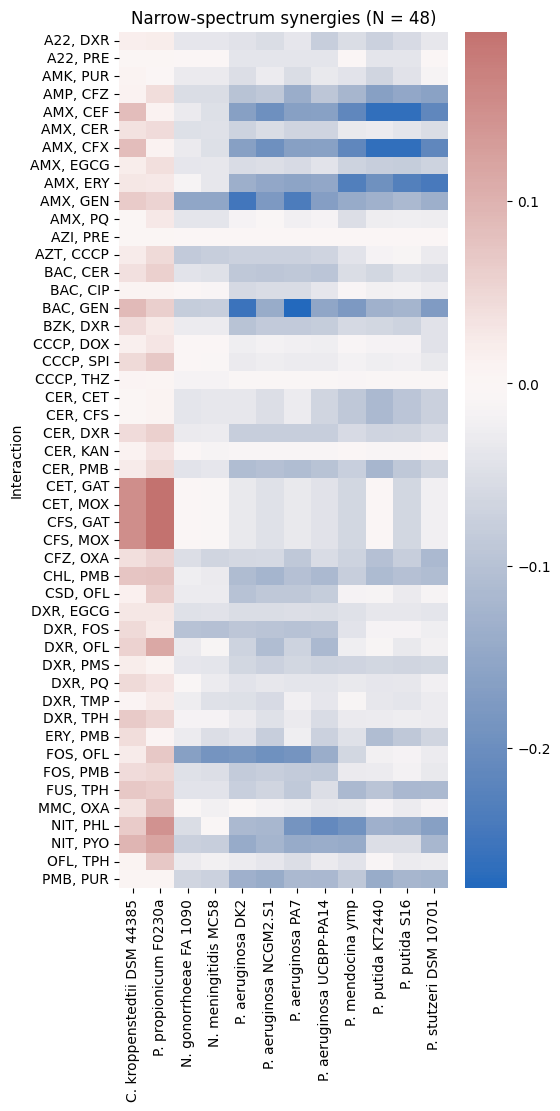

In [8]:
# Define relevant data
df          = out['endophthalmitis'].copy()
commensal   = [s for s in df.columns if s.startswith(('Coryne', 'Pro'))]
pathogens   = [s for s in df.columns if s not in commensal]
df          = df[commensal + pathogens]

# Process data
ix1         = (df[commensal] >= 0).all(axis='columns')
ix2         = (df[pathogens] < -0.2).all(axis='columns') # strong synergies
if sum(ix1 * ix2 == 1) == 0: 
    ix2 = (df[pathogens] < 0).all(axis='columns') # all synergies
    if sum(ix1 * ix2 == 1) == 0: 
        ix2 = (df[pathogens].mean(axis=1) < -0.2) # strong mean synergy
        if sum(ix1 * ix2 == 1) == 0: 
            ix2 = (df[pathogens].mean(axis=1) < 0) # mean synergy
            print('Synergy criterium based on mean across group < 0.')
        else: 
            print('Synergy criterium based on mean across group < -0.2.')
    else: 
        print('Synergy criterium based on all predictions across group < 0.')
else: 
    print('Syenrgy criterium based on all predictions across group < -0.2.')
mask = [all(ix) for ix in zip(ix1, ix2)] 
plot = df.loc[mask]

# Store data
data['endo_set'] = plot

# Generate plot
fig, axs    = plt.subplots(nrows=1, ncols=1, figsize=(5.5, 11), constrained_layout=True)
y, n        = plot[pathogens].mean(axis=1), 20
# idx         = np.argsort(y)
idx         = range(len(y))
plot.columns = [s[0] + '. ' + s.split(' ', 1)[-1] for s in plot.columns]
sns.heatmap(plot.iloc[idx], annot=False, cmap='vlag', center=0, ax=axs)
axs.set_title('Narrow-spectrum synergies (N = {})'.format(len(idx)))

# Display figure
plt.show()

##### Panel B: checkerboards

In [ ]:
# Import dependencies
from tqdm.notebook import tqdm

# Define data
d_dict = out['validation']['boards']
prefix = 'PS, '
labels = [label for label in d_dict.keys() if label.startswith(prefix)]

# Define figure dimensions
width, height = [0.1, 1, 0.1], [0.7, 0.1]
m, n, rm, rn = 3, 2, len(height), len(width)

# Instantiate figure
fig = plt.figure(figsize=(4*n, 3*m), layout='constrained')
gs = fig.add_gridspec(m*rm, n*rn, width_ratios=n*width, height_ratios=m*height)

# Generate plots
k = 0
for label in tqdm(labels, desc='Visualizing checkerboards'): 
    # Define axis coordinates
    i, j = rm*(k // n), rn*(k % n)
    # Define axis
    axes = (gs[i+1, j], gs[i+1, j+1], gs[i, j], gs[i, j+1], gs[i, j+2], gs[i+1, j+2])
    # Generate plot
    visualize_checkerboard(fig, axes, d_dict, label, annot=False, fmt='.1f', cmap='Greens')
    # Update counter
    k += 1

##### Panels C + D: MSE and % overlap of actual vs. random predictions

In [ ]:
# Import dependencies
from math import ceil, floor
from scipy.stats import ttest_1samp
from sklearn.metrics import mean_squared_error as MSE

# Load TACTIC predictions
df_pred = out['endophthalmitis'].filter(like='Pseudomonas aeruginosa').copy()

# Define true data
df_true = out['validation']['all_scores'].copy()
idx = df_true['Strain'].str.startswith('PS')
df_true = df_true[idx].reset_index(drop=True)

# Add adjusted Bliss score
dfb = df_true.filter(like='Bliss').copy()
dfb = dfb.div(dfb.abs().max())
# dfb = dfb.sub(dfb.min()).div((dfb.max() - dfb.min()))
# dfb = dfb.sub(dfb.mean()).div(dfb.std())
df_true['Bliss score (adjusted)'] = dfb.mean(axis=1)

# Extract reference points
ixns = sorted(list(df_true['Interaction'].unique()))
ixn_dict = dict(zip(ixns, range(len(ixns))))
idx = df_true['Strain'].str.endswith('MDR')
pss_ixns = list(df_true[~idx]['Interaction'])
psr_ixns = list(df_true[idx]['Interaction'])
pss_idx, psr_idx = [ixn_dict[ixn] for ixn in pss_ixns], [ixn_dict[ixn] for ixn in psr_ixns]
y_true = df_true.filter(like='score').values

In [ ]:
# Calculate MSE and % overlap
n, N = len(ixns), 100
r_pred = np.empty(shape=y_true.shape + (N,))
mse = np.empty(shape=(N, y_true.shape[1]))
polap = np.empty(shape=(N, y_true.shape[1]))
for k in range(N): 
    # Randomly sample predictions
    df_sample = df_pred.sample(n)
    # Define y_pred
    pss_pred = df_sample.iloc[pss_idx, :].filter(like='PA14').values
    psr_pred = df_sample.iloc[psr_idx, :].filter(like='PA7').values
    y_pred = np.concatenate([pss_pred, psr_pred]).reshape((-1, 1))
    y_pred = np.tile(y_pred, (1, y_true.shape[1]))
    r_pred[:, :, k] = y_pred
    # Calculate MSE
    mse[k, :] = MSE(y_true, y_pred, multioutput='raw_values')
    # Calculate % overlap
    polap[k, :] = np.divide(np.sum((y_true < 0)==(y_pred < 0), axis=0), y_true.shape[0])
    """
    for j in np.arange(0, y_pred.shape[1], 1):
        idx = y_true[:, j] < 0
        polap[k, j] = np.divide(np.sum((y_true[idx, j] < 0)==(y_pred[idx, j] < 0)), np.sum(idx))
    """
suffix = [col.replace('score ', '') for col in df_true.filter(like='score').columns]
columns = ['MSE, ' + s for s in suffix] + ['% overlap, ' + s for s in suffix]
dfr = pd.DataFrame(data=np.concatenate([mse, polap], axis=1), columns=columns)
dfr['Iteration'] = list(dfr.index)

# Determine true MSE and % overlap
ixns = [', '.join(s.split('-')) for s in df_true['Interaction']]
df_pred_true = df_pred.loc[ixns]
pss_pred = df_pred_true.filter(like='PA14')[:len(pss_ixns)].values
psr_pred = df_pred_true.filter(like='PA7')[-len(psr_ixns):].values
y_pred = np.concatenate([pss_pred, psr_pred]).reshape((-1, 1))
y_pred = np.tile(y_pred, (1, y_true.shape[1]))
mse_true = MSE(y_true, y_pred, multioutput='raw_values')
polap_true = np.divide(np.sum((y_true < 0)==(y_pred < 0), axis=0), y_true.shape[0])

# Calculate t-test statistics
td = np.empty(shape=(4, len(mse_true)))
for k in range(td.shape[1]): 
    # Conduct t-test (MSE)
    td[0, k], td[1, k] = ttest_1samp(mse[:, k], mse_true[k], alternative='greater')
    # Conduct t-test (% overlap)
    td[2, k], td[3, k] = ttest_1samp(polap[:, k], polap_true[k], alternative='less')
dft = pd.DataFrame(data=td, columns=suffix)

In [ ]:
# Visualize plots for all scores
files = {}
for k, method in enumerate(suffix): 
    # Instantiate figure
    fig = plt.figure(figsize=(9, 4.7), layout='constrained')
    gs = fig.add_gridspec(2, 2)
    
    # Define plot data
    # k = 2
    method = suffix[k]
    t1, p1, t2, p2 = dft[method].values
    va1, va2 = 'top', 'top'
    if k in [2, 3]: 
        va1 = 'bottom'
    if k == 0:
        va2 = 'bottom'
    
    # Panel A: MSE lineplot
    ax, metric = fig.add_subplot(gs[0, 0]), 'MSE'
    y = dfr[', '.join([metric, method])]
    sns.lineplot(data=dfr, x='Iteration', y=', '.join([metric, method]), ax=ax)
    ax.set_title('MSE and % overlap for {} iterations'.format(N))
    ax.set(ylim=(floor(y.min()), ceil(y.max())))
    ax.axhline(y.mean(), ls='--', color='k')
    ax.axhline(mse_true[k], ls='--', color='r')
    if va1=='top': 
        y1, y2, y3 = 0.95, 0.85, 0.75
    elif va1=='bottom': 
        y1, y2, y3 = 0.3, 0.2, 0.1
    ax.text(0.97, y1, 'Mean random {} = {:.4f}'.format(metric, y.mean()), color='k', 
        ha='right', va=va1, transform=ax.transAxes)
    ax.text(0.97, y2, 'True {} = {:.4f}'.format(metric, mse_true[k]), color='r', 
        ha='right', va=va1, transform=ax.transAxes)
    ax.text(0.97, y3, 't = {:.2f}, p = {:.2e}'.format(t1, p1), color='b', 
        ha='right', va=va1, transform=ax.transAxes)
    
    # Panel B: % overlap lineplot
    ax, metric = fig.add_subplot(gs[1, 0]), '% overlap'
    y = dfr[', '.join([metric, method])]
    sns.lineplot(data=dfr, x='Iteration', y=', '.join([metric, method]), ax=ax)
    ax.set(ylim=(floor(y.min()), ceil(y.max())))
    ax.axhline(y.mean(), ls='--', color='k')
    ax.axhline(polap_true[k], ls='--', color='r')
    if va2=='top': 
        y1, y2, y3 = 0.95, 0.85, 0.75
    elif va2=='bottom': 
        y1, y2, y3 = 0.25, 0.15, 0.05
    ax.text(0.97, y1, 'Mean random {} = {:.4f}'.format(metric, y.mean()), color='k', 
        ha='right', va=va2, transform=ax.transAxes)
    ax.text(0.97, y2, 'True {} = {:.4f}'.format(metric, polap_true[k]), color='r', 
        ha='right', va=va2, transform=ax.transAxes)
    ax.text(0.97, y3, 't = {:.2f}, p = {:.2e}'.format(t2, p2), color='b', 
        ha='right', va=va2, transform=ax.transAxes)
    
    # Panel C: true vs. prediction scatterplot
    ax = fig.add_subplot(gs[:, 1])
    x = np.tile(y_true[:, k], (1, N + 1)).reshape((-1, ))
    y = np.concatenate([r_pred[:, k, :].reshape((-1, )), y_pred[:, k]])
    df = pd.DataFrame({method: x, 'Prediction': y})
    df['Subset'] = 'Random'
    df['Subset'].iloc[len(y_true)*N:] = ['High confidence' if b=='Double effect' else 'Actual' for b in df_true['Board type']]
    cmap = {'Random': 'gray', 'Actual': 'blue', 'High confidence': 'red'}
    sns.scatterplot(data=df, x=method, y='Prediction', hue='Subset', palette=cmap, ax=ax)
    ax.axhline(0, ls='--', color='k')
    ax.axvline(0, ls='--', color='k')
    xlim, ylim = round(abs(x).max(), 1), round(abs(y).max(), 1)
    ax.set(xlim=(-xlim, xlim), ylim=(-ylim, ylim))
    ax.set_title('True vs. predicted outcomes across {} interactions'.format(len(y_true)))

#### Figure EV5: narrow-spectrum synergies (endophthalmitis)

In [ ]:
# Define relevant data
df          = out['endophthalmitis'].copy()
commensal   = [s for s in df.columns if s.startswith(('Coryne', 'Pro'))]
pathogens   = [s for s in df.columns if s not in commensal]
df          = df[commensal + pathogens]

# Process data
ix1         = (df[commensal] >= 0).all(axis='columns')
ix2         = (df[pathogens] < -0.2).all(axis='columns') # strong synergies
if sum(ix1 * ix2 == 1) == 0: 
    ix2 = (df[pathogens] < 0).all(axis='columns') # all synergies
    if sum(ix1 * ix2 == 1) == 0: 
        ix2 = (df[pathogens].mean(axis=1) < -0.2) # strong mean synergy
        if sum(ix1 * ix2 == 1) == 0: 
            ix2 = (df[pathogens].mean(axis=1) < 0) # mean synergy
            print('Synergy criterium based on mean across group < 0.')
        else: 
            print('Synergy criterium based on mean across group < -0.2.')
    else: 
        print('Synergy criterium based on all predictions across group < 0.')
else: 
    print('Syenrgy criterium based on all predictions across group < -0.2.')
mask = [all(ix) for ix in zip(ix1, ix2)] 
plot = df.loc[mask]

# Store data
data['endo_set'] = plot

# Generate plot
fig, axs    = plt.subplots(nrows=1, ncols=1, figsize=(5.5, 11), constrained_layout=True)
y, n        = plot[pathogens].mean(axis=1), 20
# idx         = np.argsort(y)
idx         = range(len(y))
plot.columns = [s[0] + '. ' + s.split(' ', 1)[-1] for s in plot.columns]
sns.heatmap(plot.iloc[idx], annot=False, cmap='vlag', center=0, ax=axs)
axs.set_title('Narrow-spectrum synergies (N = {})'.format(len(idx)))

# Display figure
plt.show()

### 1.2 Supplementary

#### Figure S1: replicated TACTIC data

In [ ]:
# Import relevant functions
from matplotlib_venn import venn3

# Define relevant data
df = master['data']
ixns = sorted(list(set(df['Interaction'])))
source, strain, metric, label = [], [], [], []
n1, n2, n3, n4, n5 = [], [], [], [], []
mini, med, maxi, sd = [], [], [], []
for ixn in ixns: 
    x = df[df['Interaction']==ixn]
    source.append(', '.join([str(s) for s in set(x['Source'])]))
    strain.append(', '.join(sorted(list(set(x['Strain'])))))
    metric.append(', '.join(sorted(list(set(x['Metric'])))))
    label.append(', '.join(sorted(list(set(x['Label'])))))
    n1.append(x.shape[0])
    # Sources 8 and 11 collected data from literature
    if any(s in (8, 11) for s in x['Source']) and n1[-1] > 1: 
        n2.append(n1[-1])
    else: 
        n2.append(len(set(x['Source'])))
    n3.append(len(set(x['Strain'])))
    n4.append(len(set(x['Metric'])))
    n5.append(len(set(x['Label'])))
    mini.append(x['Score'].min())
    med.append(x['Score'].median())
    maxi.append(x['Score'].max())
    sd.append(x['Score'].std())
dfs = pd.DataFrame({'Interaction': ixns, 'Source': source, 'Strain': strain, 'Metric': metric, 'Label': label, 
                    'N_interaction': n1, 'N_source': n2, 'N_strain': n3, 'N_metric': n4, 'N_label': n5, 
                    'Min': mini, 'Median': med, 'Max': maxi, 'SD': sd})
dfss = dfs[dfs['N_interaction'] > 1]
dfss['N_ixn_strain'] = dfss['N_interaction'] - dfss['N_strain']

# Store data
data['unique'] = dfs
data['replicated'] = dfss

# Panel A: venn diagram
df_source = dfss[dfss['N_source'] > 1]
df_strain = dfss[dfss['N_strain'] > 1]
df_metric = dfss[dfss['N_metric'] > 1]
ixns1 = set(df_source['Interaction'].tolist())
ixns2 = set(df_strain['Interaction'].tolist())
ixns3 = set(df_metric['Interaction'].tolist())
ixns = set(ixns1.union(ixns2).union(ixns3))
print(len(ixns))
ix = [i not in ixns for i in dfss['Interaction'].tolist()]
print(dfss[ix])
plt.figure(linewidth=10, edgecolor=None, facecolor=None)
venn3([ixns1, ixns2, ixns3], set_labels = ('Source', 'Strain', 'Metric'))
plt.title('Reason for replicated interactions\n(N = {})'.format(len(ixns)))
plt.show()

# Panel B: class labels barchart
dfstr = dfss[dfss['N_strain']>1]
print(dfstr.shape[0])
colors = {'Antagonism': "#FF0000", 'Neutral': "#808080", 'Synergy': "#0000FF", 
          'Antagonism, Neutral': "#FA8072", 'Neutral, Synergy': "#6495ED", 
          'Antagonism, Synergy': "#7F00FF", 'Antagonism, Neutral, Synergy': "#DA70D6"}
ax = sns.countplot(data=dfstr, y='Label', palette=colors, 
                   order=['Antagonism', 'Neutral', 'Synergy', 
                          'Antagonism, Neutral', 'Neutral, Synergy', 
                          'Antagonism, Synergy', 'Antagonism, Neutral, Synergy'])
ax.bar_label(ax.containers[0])
ax.set_xlabel('Count')
ax.set_ylabel('Class')
ax.set_title('Class agreement for interactions measured in multiple strains')
plt.show()

# Panel C: Brochado interaction examples
ixns = ['A22, MMC', 'MMC, RIF', 'BZK, EGCG', 'MMC, PRC']
ix1 = [i in ixns for i in df['Interaction'].tolist()]
ix2 = [s==1 for s in df['Source'].tolist()]
df = df[[all(ix) for ix in zip(ix1, ix2)]]
df['Class'] = df['Label']
df['Interaction'] = [s.replace(', ', ' + ') for s in df['Interaction'].tolist()]
ixns = [s.replace(', ', ' + ') for s in ixns]
colors = {'Synergy': "#004CFF", 'Neutral': "#979797", 'Antagonism': "#E00000"}
strains = ['P. aeruginosa PAO1', 'P. aeruginosa PA14', 'E. coli BW25113', 'E. coli iAi1', 
           'S. typhimurium 14028s', 'S. typhimurium LT2']
cmap = dict(zip(list(strains), [tuple(c for c in cs) for cs in sns.color_palette("Paired", len(strains))]))
sorder = ['E. coli BW25113', 'E. coli iAi1', 'P. aeruginosa PAO1', 'P. aeruginosa PA14', 
           'S. typhimurium 14028s', 'S. typhimurium LT2']
sns.stripplot(data=df, x='Interaction', y='Score', hue='Strain', order=ixns, 
              size=10, jitter=False, palette=cmap, hue_order=sorder)
plt.axhline(y=0.1, color='black', linestyle='--')
plt.text(x=0.2, y=0.12, s='Antagonism', color='black', ha='left')
plt.axhline(y=-0.1, color='black', linestyle='--')
plt.text(x=0.2, y=-0.15, s='Synergy', color='black', ha='left')
plt.title('Examples of narrow-spectrum synergies')
plt.show()

#### Figure S2: transfer learning via orthology mapping (drawn in MS PowerPoint)

#### Figure S3: train-test data split schematic (drawn in MS PowerPoint)

#### Figure S4: Gram-positive benchmarking

In [ ]:
# Instantiate figure
fig, axs   = plt.subplots(nrows=3, ncols=1, figsize=(7, 9), constrained_layout=True)

# Define data (panel A)
df = pd.read_excel('./data/ixn_data.xlsx', sheet_name='Cacace_2023', engine='openpyxl')
df1, df2 = df.groupby('Strain').count(), df.groupby(['Strain', 'Label']).count()
df1['Strain'] = [i for i in df1.index]
df2['Strain'] = [i[0] for i in df2.index]
df2['Label'] = [i[1] for i in df2.index]

# Panel A: data summary
ax = axs[0]
sns.barplot(data=df2, x='Strain', y='Interaction', hue='Label', palette=['red', 'gray', 'blue'], ax=ax)
ax.set(ylim=(0, 600), ylabel='Number of interactions', 
          title='Total number of predictable combinations (N = {})'.format(df.shape[0]))
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])
ax.legend(bbox_to_anchor=(0.15, 1), loc='upper left', ncol=3)

# Prepare data (panels B + C)
strain, ixnN        = [], []
ecoR, mtbR, tacticR, randomR = [], [], [], []
ecoM, mtbM, tacticM, randomM = [], [], [], []
rstate = RandomState(0)
for key, value in out['Cacace'].items():
    # Skip non-strain entries
    if ' ' not in key: 
        continue
    # Pull relevant data
    else: 
        # Define dataframe
        dfs = value.copy()
        dfs.rename(columns={'EC_holdout': 'EC', 'TB_holdout': 'TB', 'TACTIC_holdout': 'TACTIC'}, inplace=True)
        dfs['Random'] = rstate.permutation(dfs['TACTIC'].values)
        strain.append(key)
        ixnN.append(dfs.shape[0])
        # Spearman R
        dfr = dfs.iloc[:, 1:].corr(method='spearman')
        rvals = np.round(dfr['Score'][1:].values, 4)
        ecoR.append(rvals[0])
        mtbR.append(rvals[1])
        tacticR.append(rvals[2])
        randomR.append(rvals[3])
        # MSE
        ecoM.append(mean_squared_error(dfs['Score'], dfs['EC']))
        mtbM.append(mean_squared_error(dfs['Score'], dfs['TB']))
        tacticM.append(mean_squared_error(dfs['Score'], dfs['TACTIC']))
        randomM.append(mean_squared_error(dfs['Score'], dfs['Random']))
        # Export
        if key.startswith('B.'): 
            dfe = dfs
            dfe['Strain'] = key
        elif key.endswith(('Newman', 'D39V')): 
            dfs['Strain'] = key
            dfe = pd.concat([dfe, dfs])
dfBench = pd.DataFrame({'Strain': strain, 'Size': ixnN, 'INDIGO': ecoR, 'INDIGO-MTB': mtbR, 'TACTIC': tacticR, 'Random TACTIC': randomR})
dfMetric = pd.DataFrame({'Strain': strain, 'Metric': len(strain)*['MSE'], 'INDIGO': ecoM, 'INDIGO-MTB': mtbM, 'TACTIC': tacticM, 'Random TACTIC': randomM})
idx = [s.startswith(('B.', 'S. aureus Newman', 'S. p')) for s in dfMetric['Strain']]
df1, df2 = dfBench.copy()[idx], dfMetric.copy()[idx]

# Panel B: Spearman R
ax = axs[1]
dfPlot = pd.melt(df1, id_vars=['Strain'], value_vars=['INDIGO', 'INDIGO-MTB', 'TACTIC', 'Random TACTIC'],
        var_name='Model', value_name='Spearman R')
sns.barplot(data=dfPlot, x='Strain', y='Spearman R', hue='Model', hue_order=['INDIGO', 'INDIGO-MTB', 'Random TACTIC', 'TACTIC'], 
            palette=['green', 'purple', 'gray', 'darkorange'], ax=ax)
ax.set(ylim=(-0.1, 0.2))
ax.legend(bbox_to_anchor=(0.05, 1), loc='upper left', ncol=4)
ax.set_title('TACTIC and INDIGO performance for Gram-positive strains')

# Panel C: MSE
ax = axs[2]
dfPlot = pd.melt(df2, id_vars=['Strain'], value_vars=['INDIGO', 'INDIGO-MTB', 'TACTIC', 'Random TACTIC'],
        var_name='Model', value_name='MSE')
sns.barplot(data=dfPlot, x='Strain', y='MSE', hue='Model', hue_order=['INDIGO', 'INDIGO-MTB', 'Random TACTIC', 'TACTIC'], 
            palette=['green', 'purple', 'gray', 'darkorange'], ax=ax)
ax.set(ylim=(0, 1.5))
ax.legend(bbox_to_anchor=(0.05, 1), loc='upper left', ncol=4)

# View figure
plt.show()

In [ ]:
# Format output data
from indigopy.core import classify
dfe['Interaction'] = dfe['Ixn']
dfe['Prediction'] = dfe['TACTIC']
dfe['Label'] = classify(dfe['Score'].tolist(), thresholds=(-0.1, 0.1))
dfe['Degree'] = 2
data['Cacace'] = dfe[['Strain', 'Interaction', 'Degree', 'Score', 'Label', 'Prediction']]

#### Figure S5: GSEA results

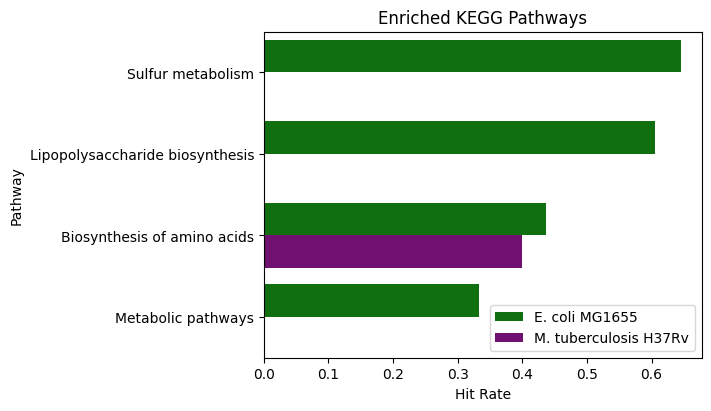

In [4]:
# Instantiate figure
fig, ax = plt.subplots(ncols=1, figsize=(7, 4), constrained_layout=True)

# Process relevant data
df1 = out['gsea']['ecoli'].copy()
df1['Organism'] = 'E. coli MG1655'
df2 = out['gsea']['mtb'].copy()
df2['Organism'] = 'M. tuberculosis H37Rv'
df = pd.concat([df1, df2])
df['Hit Rate'] = round(df['R'] / df['N'], 4)
df = df[df['padj'] < 5E-2]
df = df.sort_values(by=['Hit Rate'], ascending=False)

# Generate plot
cols = ['green' if o.startswith('E. coli') else 'purple' for o in df.Organism]
sns.barplot(data=df, x='Hit Rate', y='Pathway', hue='Organism', dodge=True, palette=['green', 'purple'], ax=ax)
ax.set_title('Enriched KEGG Pathways')
ax.legend(loc='lower right')
plt.show()

#### Figure S6: cross-species feature importance

In [ ]:
# Define list of features
tags    = ['b0115', 'b0118', 'b0844', 'b1136', 'b3041', 'b3620', 
            'b3625', 'b3628', 'b3632', 'b3737', 'b4042']
gdf     = eco_genes.loc[tags].sort_values(by='Gene')
genes   = np.repeat(gdf['Gene'].values, 2).tolist()
loci    = np.repeat(gdf.index, 2).tolist()
feat    = n * ['sigma', 'delta']
sign    = 12*['pos'] + 2*['neg'] + 2*['pos'] + 6*['neg']
flist   = ['-'.join(z) for z in zip(feat, sign, loci)]
sign    = ['+' if s=='pos' else '-' for s in sign]

# Isolate feature data
sjx     = master['data']['Label'] == 'Synergy'
ajx     = master['data']['Label'] == 'Antagonism'
labels  = master['data']['Label'][sjx | ajx]
labels  = [lab[0] for lab in labels]
fdf     = master['df'].copy()

# Instantiate figure
n = len(flist) // 4 + 1
fig, axs = plt.subplots(nrows=n, ncols=4, figsize=(2*4, 2*n), constrained_layout=True)

# Generate plots
k = 0
for idx, f in enumerate(flist): 
    i, j = k // 4, k % 4
    g, s = genes[idx], sign[idx]
    x = fdf.loc[f].values[sjx | ajx]
    # t-test for sigma values
    if f.startswith('sigma'): 
        vdf = pd.DataFrame({'Class': labels, 'Value': x})
        sns.boxplot(data=vdf, x='Class', y='Value', ax=axs[i, j])
        axs[i, j].set(xlabel='Class', ylabel='Value', title=g + ' ' + r'$\sigma$' + s)
    # chi2 test for delta values
    elif f.startswith('delta'): 
        cdf = pd.crosstab(x, labels)[['S', 'A']]
        sns.heatmap(cdf.div([sum(sjx), sum(ajx)], axis=1), annot=True, 
                    cmap='Blues', vmin=0, vmax=1, ax=axs[i, j])
        axs[i, j].set(xlabel='Class', ylabel='Value', title=g + ' ' + r'$\delta$' + s)
    k += 1

# Blank out unused axes
while k < 4*n: 
    i, j = k // 4, k % 4
    axs[i, j].axis('off')
    k += 1

# Display figure
plt.show()

#### Figure S7: strain-specific drug impact

In [ ]:
# Import relevant functions
from scipy.stats import spearmanr

# Define relevant data
idx1        = master['data']['Source']==1
dfb         = master['data'][idx1]
ixn_list    = []
for ixn in dfb['Interaction'].unique(): 
    idx = dfb['Interaction']==ixn
    if sum(idx) == 6: 
        ixn_list.append(ixn)
idx2        = [ixn in ixn_list for ixn in master['data']['Interaction']]

# Determine phylogenetic distance
idx3        = [all(s) for s in zip(idx1, idx2)]
df          = master['data'][idx3]
omap        = {key: ecoli['map'][key] + mtb['map'][key] for key in ecoli['map']}
cmap        = {k: len(v) for k, v in omap.items()}
df['N']     = df['Strain'].map(cmap)
X           = master['X'][idx3].toarray()
df['FD']    = np.sqrt(np.sum(np.square(X), axis=1) / df['N'])

# Define color palette
from matplotlib.lines import Line2D
strains     = ['E. coli BW25113', 'E. coli iAi1', 'P. aeruginosa PAO1', 'P. aeruginosa PA14', 
                'S. typhimurium 14028s', 'S. typhimurium LT2']
cmap        = dict(zip(list(strains), [tuple(c for c in cs) for cs in sns.color_palette('Paired', len(strains))]))
cmap        = {k: cmap[k] for k in strains}
handles     = [Line2D([], [], color='white', marker='o', markerfacecolor=v) for k, v in cmap.items()]
labels      = list(cmap.keys())

# Instantiate figure
n = len(ixn_list) // 4 
if len(ixn_list) % 4 > 0: 
    n += 1
fig, axs = plt.subplots(nrows=n, ncols=4, figsize=(2.25*4, 2*n), constrained_layout=True)

# Generate plots
k = 0
for ixn in sorted(ixn_list): 
    i, j = k // 4, k % 4
    ixk = df['Interaction']==ixn
    sns.scatterplot(data=df[ixk], x='FD', y='Score', hue='Strain', palette=cmap, legend=False, ax=axs[i, j])
    axs[i, j].set(xlabel='Drug impact', ylabel='Interaction score')
    r, p = spearmanr(df[ixk]['FD'], df[ixk]['Score'])
    t = '{} (R={:.1f})'.format(ixn, r)
    if p < 0.05:
        axs[i, j].set_title(t, color='red')
    else: 
        axs[i, j].set_title(t)
    k += 1
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.85,1), ncol=len(labels)/2, bbox_transform=fig.transFigure)

#### Figure S8: Biolog box plot

In [ ]:
# Import relevant functions
from scipy.stats import ttest_ind

# Load + process biolog data
biolog = pd.read_excel('./data/biolog_pm01.xlsx', sheet_name='data', engine='openpyxl')
df = biolog.pivot_table(index='Media', columns='Drug', sort=False)['AUC']
plot = df.div(df.loc['M9']).apply(np.log2).drop(index='M9')
t, p = ttest_ind(a=plot['CEF, TET'], b=plot['CEF, TOB'], equal_var=False)
print('Two-sided t-test results:\n\tt = {:.2f}\n\tp = {:.6f}'.format(t, p))

# Generate plot
ax = sns.boxplot(plot[['CEF, TET', 'CEF, TOB']], width=0.5)
ax.text(-0.14, 0.53,'$\sigma$ = {:.3f}'.format(df['CEF, TET'].std()), fontsize=10)
ax.text(0.86, 1.2,'$\sigma$ = {:.3f}'.format(df['CEF, TOB'].std()), fontsize=10)
ax.plot([0, 0, 1, 1], [1.5, 1.7, 1.7, 1.5], lw=1.5, c='k')
ax.text(0.5, 1.7, '***', ha='center', va='bottom', color='k')
ax.set(ylim=(-3, 2))
ax.set_xlabel('Drug combination')
ax.set_ylabel('Normalized cell growth')
ax.set_title('Drug interaction outcome across carbon sources (N = {})'.format(plot.shape[0]))

#### Figure S9: prediction landscape schematic (drawn in MS PowerPoint)

#### Figure S10: TACTIC prediction for CLA + beta-lactams

In [ ]:
# Define relevant data
ixns = ['AMP, CLA', 'AMX, CLA', 'AZT, CLA', 'CEF, CLA', 'CFL, CLA', 'CFS, CLA', 'CLA, MEC', 'CLA, OXA', 'AMP, CLA, MEC']
df = pd.concat((out['landscape']['lb'].copy(), out['AMP-CLA-MEC'].copy()))
df.index = [i.replace(', LB', '') for i in df.index]
df.columns = [s[0] + '. ' + s.split(' ', 1)[-1] if '.' not in s else s for s in df.columns]

# Generate plot
ax = sns.heatmap(df.loc[ixns], cmap='vlag', center=0)
ax.set_title('Predictions for CLA + beta-lactams')

#### Figure S11: TACTIC prediction for literature validation (P. aeruginosa)

In [ ]:
# Instantiate figure
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4.5, 4), constrained_layout=True)
fig.set_facecolor('white')

# Define data
df          = out['endophthalmitis'].copy()
commensal   = [s for s in df.columns if s.startswith(('Coryne', 'Pro'))]
pathogens   = [s for s in df.columns if s not in commensal]
paeruginosa = [s for s in pathogens if 'aeruginosa' in s]
ixns1       = ['GAT, MOX', 'CFZ, CIP', 'CFZ, TOB', 'CIP, TOB']
ixns2       = ['AMK, PMB', 'AZT, PMB', 'CHL, PMB', 'CIP, PMB', 
                'FOS, PMB', 'LIN, PMB', 'MIN, PMB', 'PMB, RIF', 'PMB, TMP']
ixns        = ixns1 + ixns2 
evidence    = ['*', 'N', 'S', 'N', '–', 'S', 'S', '–', 'S', '–', 'S', 'S', 'N']
labels      = [i + ' (' + e + ')' for i, e in zip(ixns, evidence)]
plot        = df[paeruginosa]
plot.columns = [s[0] + '. ' + s.split(' ', 1)[-1] for s in plot.columns]

# Generate plot
sns.heatmap(plot.loc[ixns], annot=False, cmap='vlag', center=0, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, horizontalalignment='right')
ax.set_yticklabels(labels)
ax.set_title('Literature validation (N = {})'.format(len(ixns)))

#### Figure S12: dose response matrices for P. aeruginosa

See end of notebook

#### Figure S14: Bliss vs. Loewe score agreement

In [ ]:
# Import dependencies
from scipy.stats import pearsonr

# Define relevant data
df = master['data'].copy()
df = df[df['Source']!=7]
dfm = dfss[dfss['N_metric']==2]
ixns = dfm['Interaction'].to_list()

# Process data
k = 0
for ixn in ixns: 
    dfi = df[df['Interaction']==ixn]
    for strain in dfi['Strain'].unique(): 
        dfs = dfi[dfi['Strain']==strain]
        if len(dfs['Metric'].unique())==2: 
            dfs = dfs[['Interaction', 'Strain', 'Metric', 'Score']]
            if k==0: 
                dfp = dfs.pivot_table(index=['Interaction', 'Strain'], columns='Metric', sort=False)['Score']
                k =+ 1
            else: 
                dfp = pd.concat([dfp, dfs.pivot_table(index=['Interaction', 'Strain'], columns='Metric', sort=False)['Score']])
dfp['Strain'] = [i[-1] for i in dfp.index]
r, p = pearsonr(dfp['Bliss'], dfp['Loewe'])

# Generate figure
ax = sns.scatterplot(data=dfp, x='Bliss', y='Loewe', hue='Strain')
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
ax.set_title('Agreement between Bliss and Loewe scores')
ax.text(0.02, 0.98, 'N = {}\nR = {:.3f}\np = {:.0e}'.format(dfp.shape[0], r, p), 
        ha='left', va='top', transform=ax.transAxes)
ax.legend(loc='lower right')

#### Figure S15: ML algorithm comparison

In [ ]:
# Extract alternative ML results
strains = [s for s in out['bench'].keys() if ' ' in s]
MLdict  = out['bench']['ML'].copy()
k       = 0
for key, value in MLdict.items(): 
    # Define algorithm name
    if key.startswith('Linear'): 
        alg = 'Linear'
    elif key.startswith('Decision'): 
        alg = 'DTR'
    elif key.startswith('Gradient'): 
        alg = 'GBR'
    else: 
        alg = key
    # Extract data
    rlist, mlist = [], []
    for strain in strains: 
        # Spearman R
        dfr = value[strain].iloc[:, 1:].corr(method='spearman')
        rvals = np.round(dfr['Score'][1:].values, 4)
        rlist.append(rvals[2])
        # MSE
        dfs = value[strain].copy()
        dfs.rename(columns={'TACTIC_holdout': 'TACTIC'}, inplace=True)
        mlist.append(mean_squared_error(dfs['Score'], dfs['TACTIC']))
    # Define output
    if k==0: 
        plot = pd.DataFrame({'Strain': strains, 'Algorithm': len(strains)*[alg], 'R': rlist, 'M': mlist})
    else: 
        plot = pd.concat([plot, pd.DataFrame({'Strain': strains, 'Algorithm': len(strains)*[alg], 'R': rlist, 'M': mlist})])
    # Update counter
    k += 1

# Add RF results
rlist, mlist = [], []
for strain in strains: 
    # Spearman R
    dfr = out['bench'][strain].iloc[:, 1:].corr(method='spearman')
    rvals = np.round(dfr['Score'][1:].values, 4)
    rlist.append(rvals[2])
    dfs = out['bench'][strain].copy()
    dfs.rename(columns={'TACTIC_holdout': 'TACTIC'}, inplace=True)
    mlist.append(mean_squared_error(dfs['Score'], dfs['TACTIC']))
plot = pd.concat([plot, pd.DataFrame({'Strain': strains, 'Algorithm': len(strains)*['RFR'], 'R': rlist, 'M': mlist})])
plot.rename(columns={'R': 'Spearman R', 'M': 'MSE'}, inplace=True)

# Instantiate figure
fig, axs    = plt.subplots(nrows=2, ncols=1, figsize=(10, 9), constrained_layout=True)

# Panel A: Spearman R bar chart
sns.barplot(data=plot, x='Strain', y='Spearman R', hue='Algorithm', palette='tab10', ax=axs[0])
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=20, horizontalalignment='right')
axs[0].legend(loc='lower center', ncol=3)
axs[0].set_title('ML algorithm comparison for TACTIC')
axs[0].set(ylim=(-0.3, 0.8))

# Panel B: MSE bar chart
sns.barplot(data=plot, x='Strain', y='MSE', hue='Algorithm', palette='tab10', clip_on=False, ax=axs[1])
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=20, horizontalalignment='right')
axs[1].legend(loc='upper center', ncol=3)

# Show figure
plt.show()

# Instantiate figure
fig, axs    = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), constrained_layout=True)

# Panel C: Spearman R boxplot
dfBench = pd.pivot_table(plot, index='Strain', columns='Algorithm', sort=False)['Spearman R']
sns.boxplot(dfBench, ax=axs[0])
axs[0].set_ylabel('Spearman R')
axs[0].set_title('Spearman R distribution')

# Panel D: MSE boxplot
dfMetric = pd.pivot_table(plot, index='Strain', columns='Algorithm', sort=False)['MSE']
sns.boxplot(dfMetric, ax=axs[1])
axs[1].set_ylabel('MSE')
axs[1].set_title('MSE distribution')

# Show figure
plt.show()

#### Figure S16: adjusted p-value distribution

In [ ]:
# Define relevant data
df = out['gsea']['features'].copy()
df['-log10(padj)'] = -np.log10(df['padj'].values)

# Generate plot
sns.histplot(data=df, x='-log10(padj)', binwidth=1)
plt.axvline(x=6, color='black', linestyle='--')
plt.text(x=6.5, y=100, s='Threshold', color='black', ha='left')
plt.title('Adjusted p-value distribution (feature significance)')
plt.show()

#### Figure S17: image-processing of Van et al. data (Figure 2A)

In [ ]:
# Panels A + B: original and reduced heatmap images
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 3), constrained_layout=True)
hm = out['Van']['original']
ax[0].imshow(hm)
ax[0].set_title('Original heatmap ({} x {})'.format(hm.shape[0], hm.shape[1]))
hm = out['Van']['reduced']
ax[1].imshow(hm)
ax[1].set_title('Reduced heatmap ({} x {})'.format(hm.shape[0], hm.shape[1]))

# Panel C (drawn in MS PowerPoint)

# Panels D + E: inferred score distribution and heatmap
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), width_ratios=(5, 4), constrained_layout=True)
hm = out['Van']['scores']
x = hm.reshape(-1)
sns.histplot(x, ax=ax[0])
ax[0].set(xlabel='Score', ylabel='Count', title='Image-inferred scores (capped)')
ax[0].text(1, 60, 'N = {}'.format(sum(~np.isnan(x))))
nan_mask = np.isnan(hm)
cmap = sns.color_palette('vlag', as_cmap=True).copy()
cmap.set_bad('gray')
sns.heatmap(hm, center=0, cmap=cmap, mask=nan_mask, ax=ax[1])
ax[1].set_title('Inferred score heatmap')

## 2. Tables

Construct main and supplementary tables.

### 2.1 Main

#### Table 1: TACTIC data collection

In [ ]:
# Define relevant data
df = master['data']
strains = sorted(list(set(df['Strain'])))
n, n3, metric, syn, add, ant = [], [], [], [], [], []
for s in strains: 
    x = df[df['Strain']==s]
    n.append(x.shape[0])
    n3.append(sum(x['Degree'] > 2))
    metric.append(', '.join(sorted(list(set(x['Metric'])))))
    syn.append(sum(x['Label'] == 'Synergy'))
    add.append(sum(x['Label'] == 'Neutral'))
    ant.append(sum(x['Label'] == 'Antagonism'))
dfx = pd.DataFrame({'Strain': strains, 'N': n, 'N3': n3, 'Metric': metric, 
                    'Synergy': syn, 'SynP': [round(x1 / x2, 4) for x1, x2 in zip(syn, n)], 
                    'Additive': add, 'AddP': [round(x1 / x2, 4) for x1, x2 in zip(add, n)], 
                    'Antagonism': ant, 'AntP': [round(x1 / x2, 4) for x1, x2 in zip(ant, n)]})

# View table
display(dfx)

#### Table 2: feature important genes

In [ ]:
# Define relevant data
tags = ['b0115', 'b0118', 'b0844', 'b1136', 'b3041', 'b3620', 
        'b3625', 'b3628', 'b3632', 'b3737', 'b4042']
efdf = eco_genes[[g in tags for g in eco_genes.index]]
efdf = efdf.sort_values(by=['Pathway'])

# View table
display(efdf)

#### Table 3: literature-based evidence (manually curated in MS Word)

### 2.2 Supplementary

#### Table S1: endophthalmitis antibiotics (manually curated in MS Word)

#### Table S2: endophthalmitis strains (manually curated in MS Word)

#### Table S3: PCA strain-to-strain cumulative distance

In [ ]:
# Import relevant functions
from sklearn.metrics.pairwise import pairwise_distances

# Define relevant data
n = out['landscape']['lb'].shape[1]
cd = []
for k, m in enumerate(media): 
    j1, j2 = k*n, (k+1)*n
    x = components[:, j1:j2]
    d = pairwise_distances(x, metric='euclidean')
    cd.append(np.sum(d)/2)
cdf = pd.DataFrame({'Media': media, 'CD': cd})
cdf.sort_values(by='CD', ascending=False, inplace=True)

# View table
display(cdf)

#### Table S4: indication of which ixns were measured (manually done in MS Word)

## 3. Data

Format and save supplementary data.

### Data S1: drug interaction metadata (manually curated in MS Excel)

### Data S2: TACTIC data

In [ ]:
# Export to Excel
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	data['TACTIC'].to_excel(file, sheet_name='Data S2', index=False, engine='openpyxl', freeze_panes=(1, 1))

### Data S3: TACTIC drugs (manually curated in MS Excel)

### Data S4: unique drug interactions

In [ ]:
# Export to Excel
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	data['unique'].to_excel(file, sheet_name='Data S4', index=False, engine='openpyxl', freeze_panes=(1, 1))

### Data S5: Cacace et al. data

In [ ]:
# Export to Excel
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	data['Cacace'].to_excel(file, sheet_name='Data S5', index=False, engine='openpyxl', freeze_panes=(1, 1))

### Data S6: prediction landscape

In [ ]:
# Add 3-way prediction
df = out['AMP-CLA-MEC'].copy()
df.columns  = [s[0] + '. ' + s.split(' ', 1)[-1] if '.' not in s else s for s in df.columns]
df = df.melt(var_name='Strain', value_name='Prediction', ignore_index=False)
df['Interaction'] = df.index.values
df['Media'] = df.shape[0]*['LB']
df = df[data['landscape'].columns]
dfp = pd.concat([data['landscape'].copy(), df])

# Export to Excel (runtime: ~1 minute)
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	dfp.to_excel(file, sheet_name='Data S6', index=False, engine='openpyxl', freeze_panes=(1, 1))

### Data S7: Van et al. data

In [ ]:
# Export to Excel (runtime: ~2 minutes)
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	data['Van'].to_excel(file, sheet_name='Data S7', index=False, engine='openpyxl', freeze_panes=(1, 1))

### Data S8: endophthalmitis prediction landscape

In [ ]:
# Export to Excel (runtime: ~2 minutes)
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	data['endophthalmitis'].to_excel(file, sheet_name='Data S8', index=True, engine='openpyxl', freeze_panes=(1, 1))

### Data S9: endophthalmitis narrow-spectrum predictions

In [ ]:
# Export to Excel (runtime: ~2 minutes)
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	data['endo_set'].to_excel(file, sheet_name='Data S9', index=True, engine='openpyxl', freeze_panes=(1, 1))

### Data S10: in-house experimental data (manually curated in MS Excel)

### Data S11: TACTIC feature importance

In [ ]:
# Export to Excel (runtime: ~2 minutes)
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	data['importance'].to_excel(file, sheet_name='Data S11', index=True, engine='openpyxl', freeze_panes=(1, 1))

### Data S12: GSEA feature significance

In [ ]:
# Export to Excel (runtime: ~2 minutes)
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	out['gsea']['features'].to_excel(file, sheet_name='Data S12', index=True, engine='openpyxl', freeze_panes=(1, 1))

## X. Extra Material

New material, re-locate within main headers.

### Data: manual and SynergyFinder scores for experimental validation data

In [ ]:
# Export to Excel (runtime: ~2 minutes)
df = out['validation']['all_scores'].copy()
strains = ('ATCC', 'Smooth', 'Rough', 'PS')
cols = ['Strain', 'Interaction', 'Board type', 'Bliss score (Manual)', 'Bliss score (SynergyFinder)']
df = df[df['Strain'].str.startswith(strains)][cols]
with pd.ExcelWriter('./data/TACTIC_output.xlsx', mode='a', if_sheet_exists='replace') as file:
	df.to_excel(file, sheet_name='Data SX', index=False, engine='openpyxl', freeze_panes=(1, 1))

### Figure: checkerboards for experimental data 

Runtime: 
* ~15 minutes for P. aeruginosa only (N = 93)
* ~20 minutes for all but S. epidermidis (N = 153)
* ~35 minutes for all checkerboards (N = 198)

In [ ]:
# Define data
d_dict = out['validation']['all_boards']
# prefix = ('ATCC', 'Smooth', 'Rough', 'PS', 'SA')
prefix = ('PS', 'SA')
labels = [label for label in d_dict.keys() if label.startswith(prefix)]
df = out['validation']['all_scores'].copy()
highlight = df[df['Board type']=='Double effect']['Label'].tolist()

# Define figure dimensions
width, height = [0.1, 1, 0.1], [0.7, 0.1]
m, n, rm, rn = 6, 3, len(height), len(width)
rows = len(labels) // n
if len(labels) % n > 0:
    rows += 1
pages = rows // m
if rows % m > 0:
    pages += 1

# Plot checkerboards
files = {}
for page in tqdm(range(0, pages), desc='Generating pages'):
    # Adjust row length based on page
    if page == pages - 1:
        k, start, end = 0, page*(m*n), len(labels)
        items = len(labels) - page*m*n
        m = items // n
        if items % n > 0:
            m += 1
    else:
        k, start, end = 0, page*(m*n), (page+1)*m*n
    # Instantiate figure
    fig = plt.figure(figsize=(4.5*n, 3*m), layout='constrained')
    gs = fig.add_gridspec(m*rm, n*rn, width_ratios=n*width, height_ratios=m*height)
    # Generate plots
    for label in tqdm(labels[start:end], desc='Visualizing checkerboards', leave=False): 
        # Define axis coordinates
        if ('Smooth, AMP-CLA' in labels) and (page == 0) and (k < 5): 
            if 'MEC' in label: 
                if label.startswith('ATCC'): 
                    p = 3
                else: 
                    p = 4
            else: 
                p = k // 2
            i, j = rm*(p // n), rn*(p % n)
        else: 
            i, j = rm*(k // n), rn*(k % n)
        # Define axis
        axes = (gs[i+1, j], gs[i+1, j+1], gs[i, j], gs[i, j+1], gs[i, j+2], gs[i+1, j+2])
        # Account for source
        flip = label.startswith(('ATCC', 'Smooth', 'Rough', 'PS4'))
        if label in highlight:
            color = 'r'
        else:
            color = 'k'
        # Generate plot
        visualize_checkerboard(fig, axes, d_dict, label, annot=False, fmt='.1f', cmap='Greens', flip=flip, color=color)
        # Update counter
        k += 1
    # Save figure
    files[page] = fig